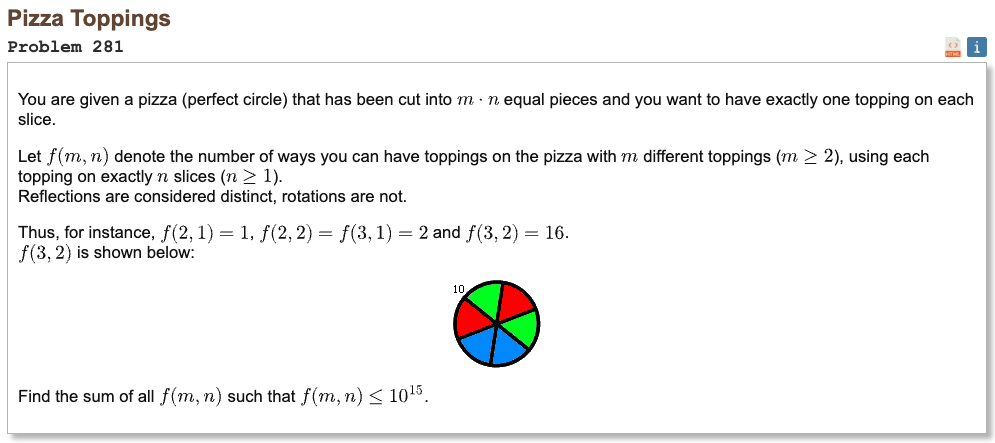

## Initial approach

* treat the pizza as a circular arrangement where rotations count as the same but reflections still count as different
* use Burnside’s lemma on rotations, so for each rotation you count how many topping patterns stay unchanged
* a rotation only works when each topping can be spread evenly across its repeating position groups
* that turns the counting into checking divisors of the repeat count and adding the valid symmetric arrangements
* for each valid case, count how many ways the repeating groups can be assigned to toppings using factorials
* then divide by the number of slices to remove rotational duplicates
* the values grow very fast, so only small pairs need to be checked before the count passes the limit
* use math for factorials and integer square root

In [1]:
from math import factorial, isqrt

LIMIT = 10**15

def divisors(n):
    result = []
    for i in range(1, isqrt(n) + 1):
        if n % i == 0:
            result.append(i)
            if i * i != n:
                result.append(n // i)
    return result

def phi(n):
    result = n
    x = n
    p = 2
    while p * p <= x:
        if x % p == 0:
            while x % p == 0:
                x //= p
            result -= result // p
        p += 1
    if x > 1:
        result -= result // x
    return result

def f(m, n, facts):
    total = 0
    for d in divisors(n):
        total += phi(n // d) * facts[m * d] // (facts[d] ** m)
    return total // (m * n)

def solve():
    max_m = 18
    max_n = 30
    facts = [1] * (max_m * max_n + 1)
    for i in range(1, len(facts)):
        facts[i] = facts[i - 1] * i

    result = 0

    for m in range(2, max_m + 1):
        if f(m, 1, facts) > LIMIT:
            break
        n = 1
        while True:
            value = f(m, n, facts)
            if value > LIMIT:
                break
            result += value
            n += 1

    return result

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 1485776387445623
CPU times: user 684 μs, sys: 114 μs, total: 798 μs
Wall time: 758 μs
